Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1077af670>>
Traceback (most recent call last):
  File "/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Device: mps
Loading finetuned ensemble...
  loaded 5 members
Loading test data...
  CNRM-CM6-1                     [ARPEGE]  29 members
  CESM2-LENS2_cmip6              [CCM0B]  50 members
  CanESM5-1_p1                   [CanAM3]  47 members
  EC-Earth3                      [EC-Earth3]  72 members
  MPI-ESM1-2-LR                  [ECHAM0]  45 members
  ACCESS-ESM1-5                  [HadAM3]  40 members
  INM-CM5-0                      [INM]  10 members
  IPSL-CM6A-LR                   [IPSL]  33 members
  MIROC6                         [MIROC]  50 members
  GISS-E2-1-G_p1                 [UCLA]  28 members
Auto-selected: CanESM5-1_p1 (RMSE=0.2942)


/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3

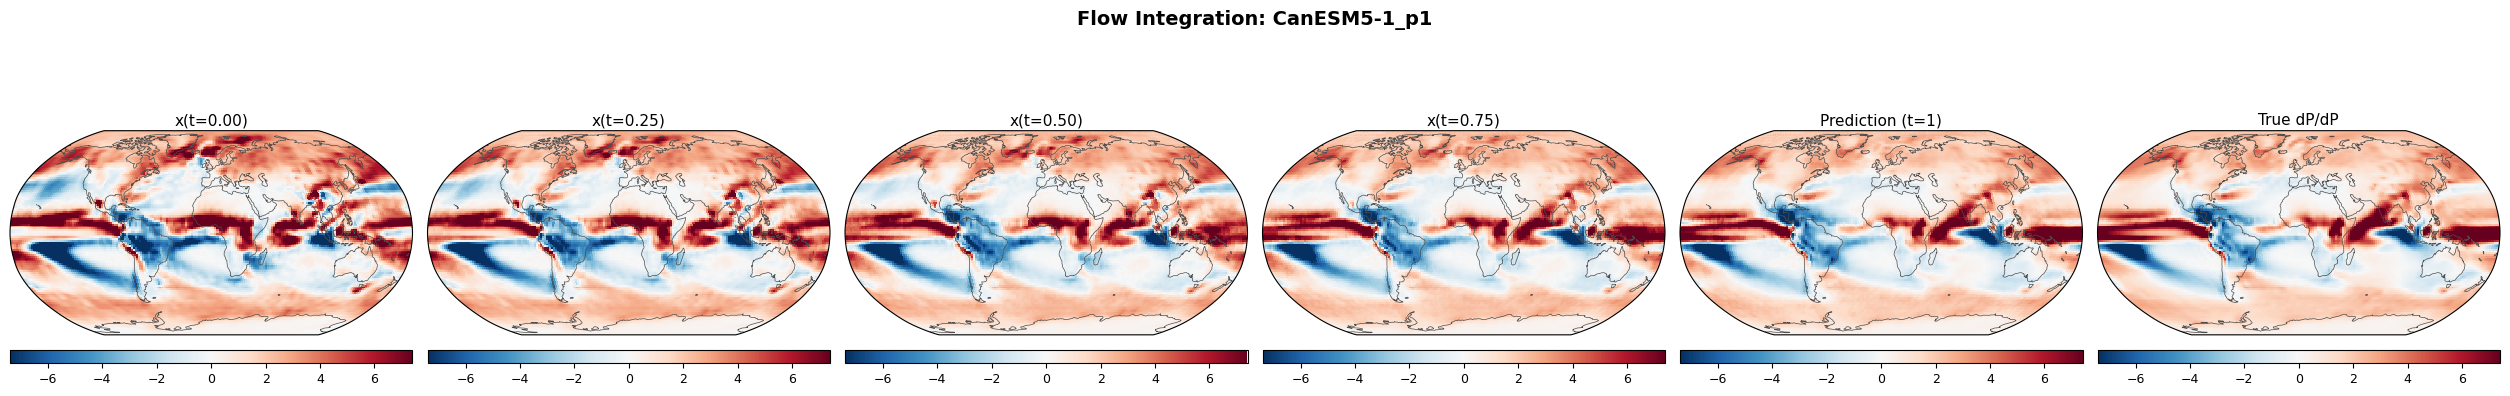

Saved fig_integration_sequence.png


/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3

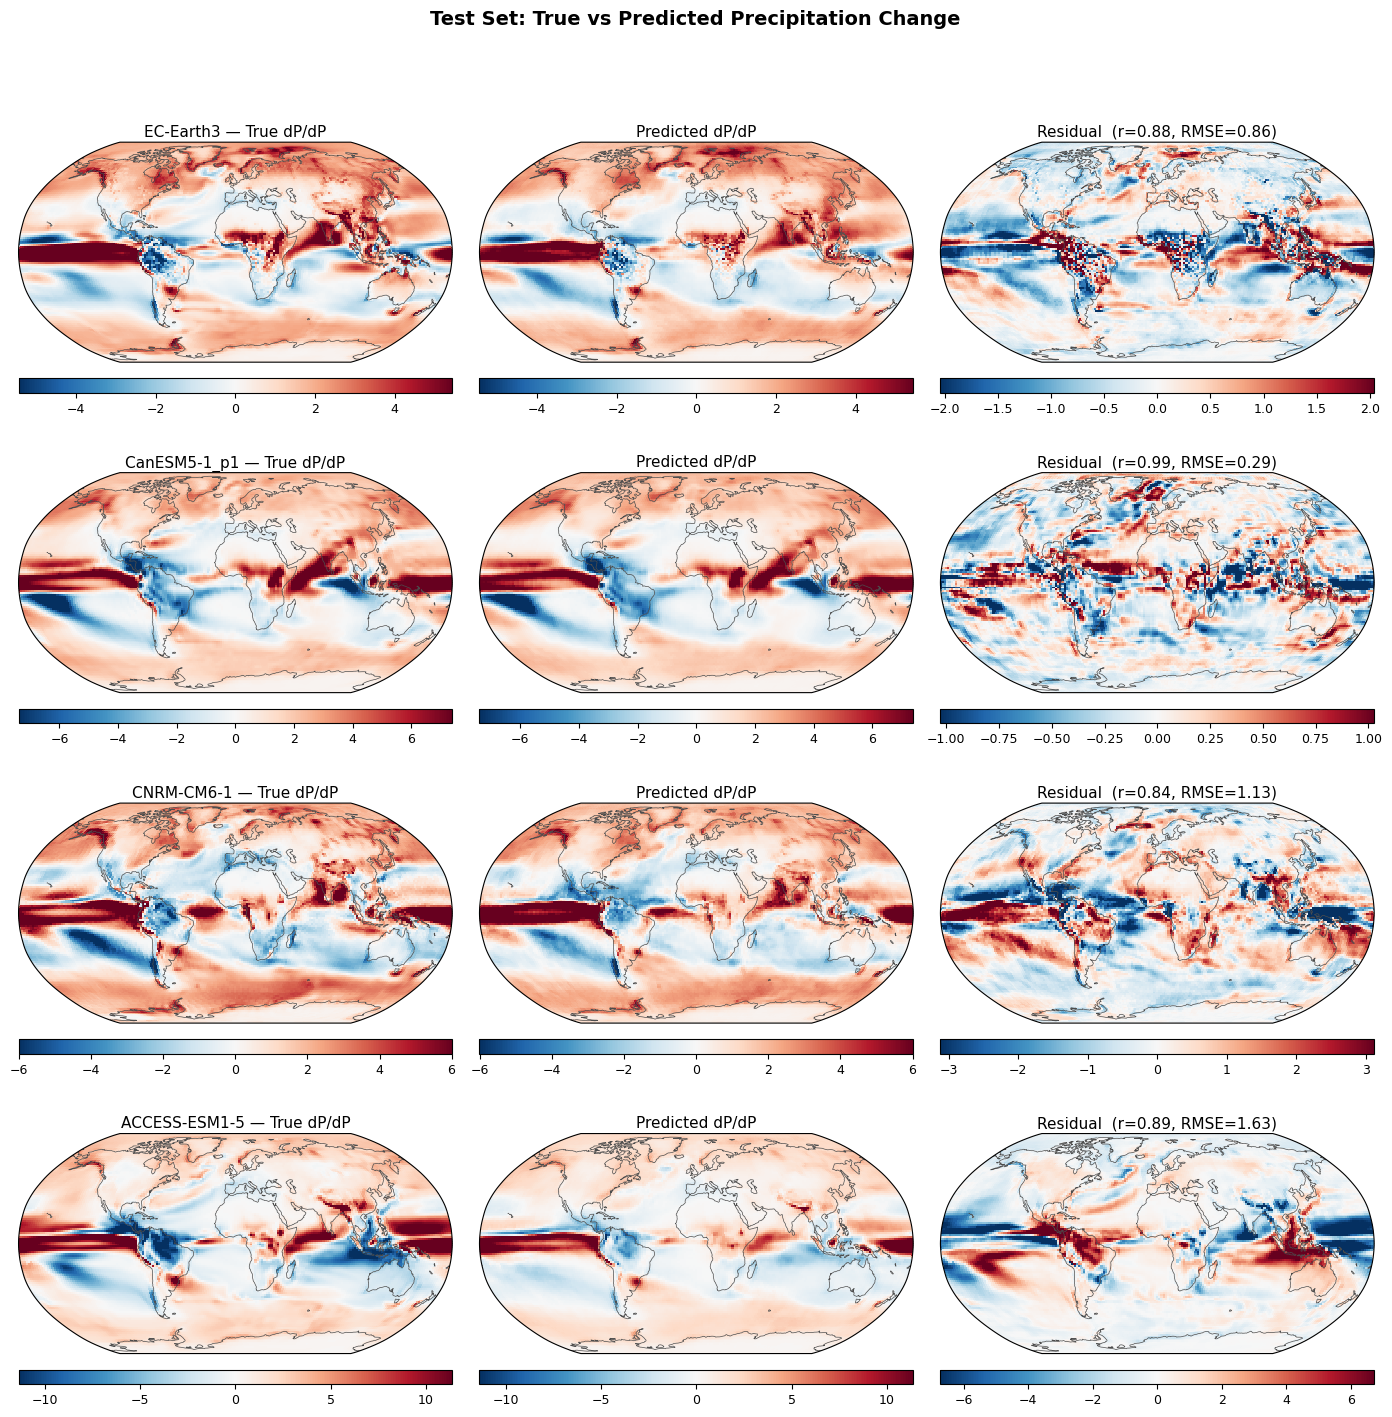

Saved fig_test_maps.png


/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


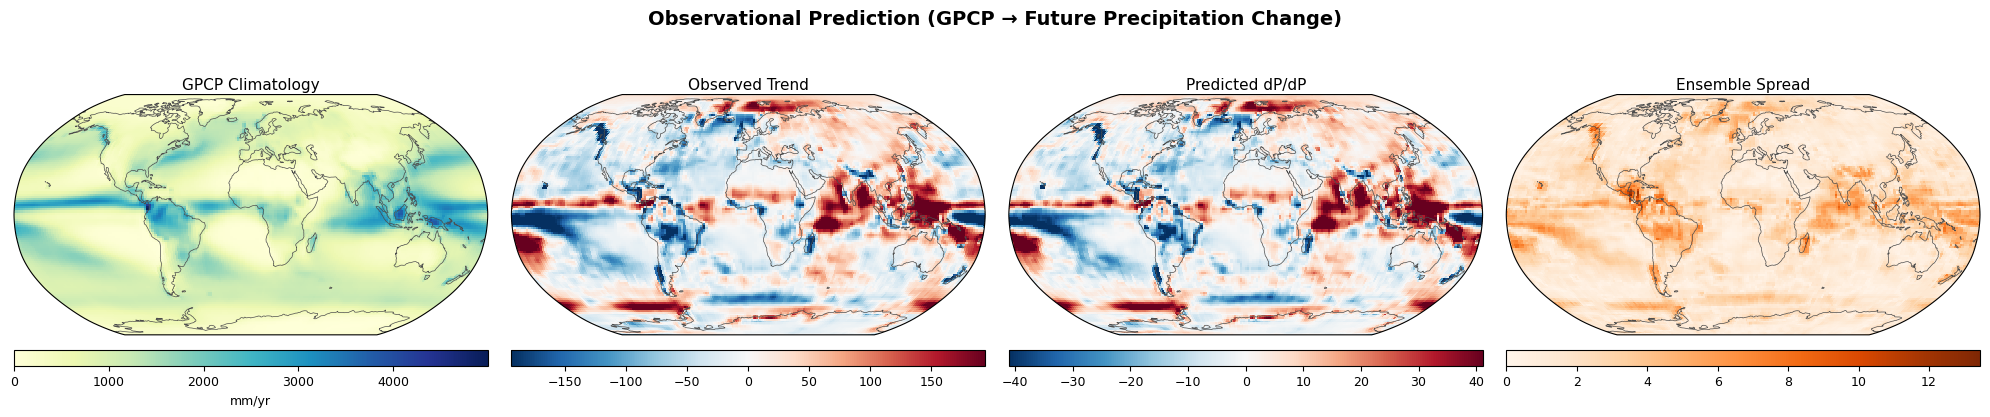

Saved fig_gpcp_prediction.png


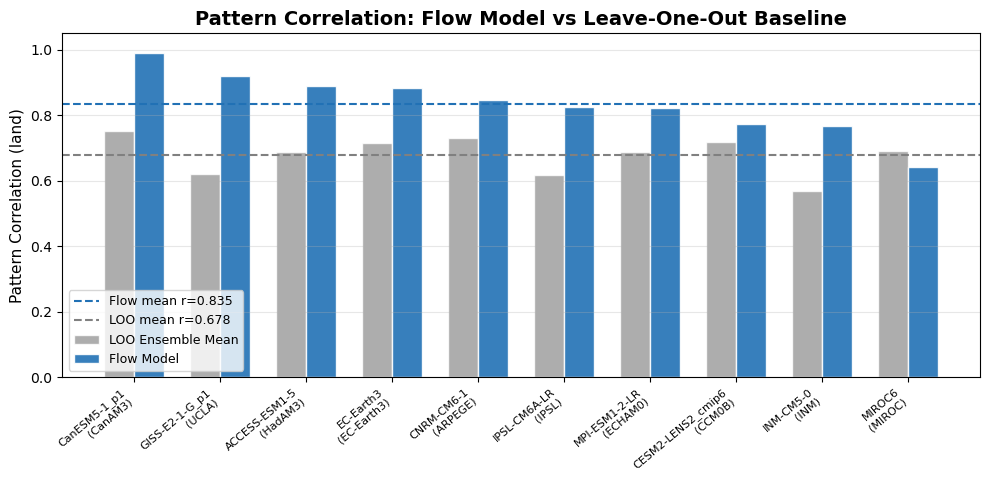

Saved fig_pattern_correlation.png


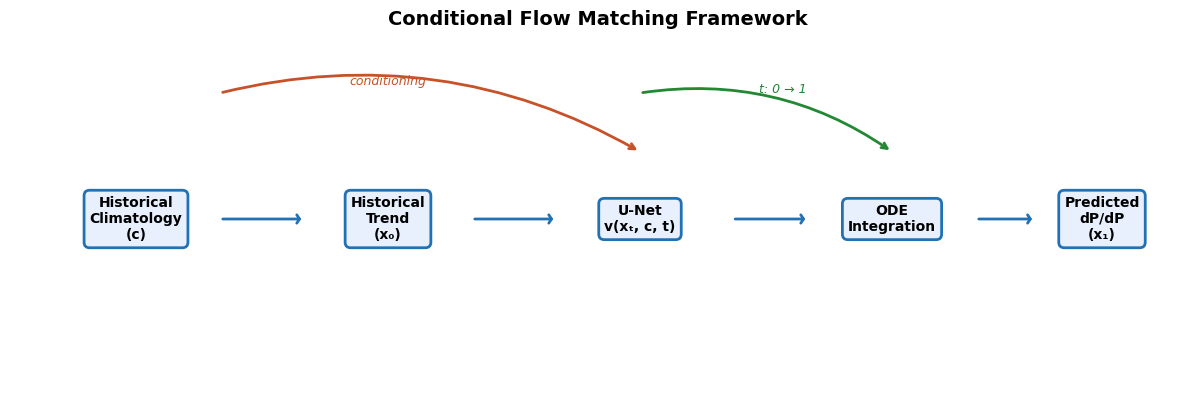

Saved fig_method_schematic.png

All poster figures saved to /Users/ewellmeyer/Documents/research/weights/flow_finetune_unet6R_ch8_oce0.1_aug0.8/poster_figures


In [1]:
# %% [markdown]
# # Poster Figure Generation
# Produces publication-quality figures for the conference poster.
# Run cells top-to-bottom, or change DEMO_MODEL / HIGHLIGHT_MODELS to try
# different test cases.

# %%
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from flow_models import Unet6R
from cmip6_split import TEST_GROUPS, TRAIN_GROUPS, VAL_GROUPS, group_family

# ── configuration ──────────────────────────────────────────────────────────────

CMIP6_DIR      = Path("/Users/ewellmeyer/Documents/research/CMIP6/processed_by_model")
LANDMASK_PATH  = Path("/Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc")
PPE_GRID_PATH  = Path("/Users/ewellmeyer/Documents/research/HadGEM/GA789_PR_his_rg128.nc")
WEIGHTS_DIR    = Path("/Users/ewellmeyer/Documents/research/weights")

BASE_CHANNELS  = 8
FINETUNE_EXPT  = (f"flow_finetune_unet6R_ch{BASE_CHANNELS}_oce0.1_aug0.8")
BASE_EXPT      = f"flow_base_unet6R_ch{BASE_CHANNELS}_land10_oce0.3_aug0.8"
FT_DIR         = WEIGHTS_DIR / FINETUNE_EXPT
BASE_DIR       = WEIGHTS_DIR / BASE_EXPT

FIG_DIR        = FT_DIR / "poster_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_ENSEMBLE     = 5
ODE_STEPS      = 20
P_DROP         = 0.0

# ── CHANGE THESE to try different models ──
DEMO_MODEL = None  # set to e.g. "CanESM5-1_p1" or None for auto (best RMSE)
HIGHLIGHT_MODELS = ["EC-Earth3", "CanESM5-1_p1", "CNRM-CM6-1", "ACCESS-ESM1-5"]

# poster styling
TITLE_SIZE = 14
LABEL_SIZE = 11
CBAR_SIZE  = 9

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

# %% [markdown]
# ## Load grid, models, data

# %%
# target grid
ds_grid = xr.open_dataset(PPE_GRID_PATH)
lat_name = "latitude" if "latitude" in ds_grid.coords else "lat"
lon_name = "longitude" if "longitude" in ds_grid.coords else "lon"
target_lat = ds_grid.coords[lat_name].values.astype(np.float64)
target_lon = ds_grid.coords[lon_name].values.astype(np.float64)
ds_grid.close()

# clim stats
stats_path = FT_DIR / "clim_stats.json"
if not stats_path.exists():
    stats_path = BASE_DIR / "clim_stats.json"
with open(stats_path) as f:
    stats = json.load(f)
clim_mean, clim_std = stats["clim_mean"], stats["clim_std"]

# land mask
ds_mask = xr.open_dataset(LANDMASK_PATH)
land_frac = ds_mask[list(ds_mask.data_vars)[0]].values.astype(np.float32)
land_flat = land_frac.reshape(-1) > 0.5

# finetuned ensemble
print("Loading finetuned ensemble...")
ft_models = []
for mi in range(N_ENSEMBLE):
    p = FT_DIR / f"best_member{mi}.pth"
    if not p.exists(): continue
    ckpt = torch.load(p, map_location=DEVICE)
    m = Unet6R(input_channels=2, output_channels=1,
               base_channels=BASE_CHANNELS, p_drop=P_DROP).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"]); m.eval()
    ft_models.append((mi, m))
print(f"  loaded {len(ft_models)} members")

# %%
# load test data
print("Loading test data...")


def load_group(name, data_dir):
    clim_path  = data_dir / f"{name}_clim.nc"
    trend_path = data_dir / f"{name}_trend.nc"
    dpdp_path  = data_dir / f"{name}_dPdP.nc"
    if not all(p.exists() for p in [clim_path, trend_path, dpdp_path]):
        return None
    ds_c = xr.open_dataset(clim_path)
    clim = ds_c["pr_clim"].values.astype(np.float32); ds_c.close()
    ds_t = xr.open_dataset(trend_path)
    trend = ds_t["pr_trend"].values.astype(np.float32); ds_t.close()
    if trend.ndim == 2: trend = trend[np.newaxis, :, :]
    ds_d = xr.open_dataset(dpdp_path)
    dpdp = ds_d["dPdP"].values.astype(np.float32); ds_d.close()
    return dict(clim=clim, trends=trend, dpdp=dpdp, n_members=trend.shape[0])


test_data = {}
for name, family in TEST_GROUPS:
    data = load_group(name, CMIP6_DIR)
    if data is not None:
        data["name"]   = name
        data["family"] = family
        test_data[name] = data
        print(f"  {name:<30} [{family}]  {data['n_members']} members")

# %% [markdown]
# ## Helper functions

# %%
@torch.no_grad()
def integrate(model, x0, clim, steps=20):
    x = x0.clone()
    dt = 1.0 / steps
    for i in range(steps):
        t_val = i * dt
        t = torch.full((x.shape[0],), t_val, device=x.device)
        v = model(x, clim, t)
        x = x + v * dt
    return x


@torch.no_grad()
def integrate_with_snapshots(model, x0, clim, steps=20,
                              snapshot_times=(0.0, 0.25, 0.5, 0.75, 1.0)):
    x = x0.clone()
    dt = 1.0 / steps
    snaps = {0.0: x.cpu().numpy()[0, 0].copy()}
    for i in range(steps):
        t_val = i * dt
        t = torch.full((x.shape[0],), t_val, device=x.device)
        v = model(x, clim, t)
        x = x + v * dt
        t_after = (i + 1) * dt
        for st in snapshot_times:
            if abs(t_after - st) < dt / 2 and st not in snaps:
                snaps[st] = x.cpu().numpy()[0, 0].copy()
    return snaps


def predict_ensemble(models, x0_np, clim_np):
    clim_norm = np.nan_to_num((clim_np - clim_mean) / (clim_std + 1e-6))
    x0_clean  = np.nan_to_num(x0_np)
    clim_t = torch.from_numpy(clim_norm[None, None]).float().to(DEVICE)
    x0_t   = torch.from_numpy(x0_clean[None, None]).float().to(DEVICE)
    preds = []
    for _, m in models:
        pred = integrate(m, x0_t, clim_t, steps=ODE_STEPS)
        preds.append(pred.cpu().numpy()[0, 0])
    return preds


def land_rmse(pred, true):
    return np.sqrt(np.mean(((pred - true).reshape(-1)[land_flat]) ** 2))


def land_corr(pred, true):
    p = pred.reshape(-1)[land_flat]
    t = true.reshape(-1)[land_flat]
    return np.corrcoef(p, t)[0, 1]


def map_panel(ax, data, title, cmap="RdBu_r", vmin=None, vmax=None,
              symmetric=False, colorbar=True, cb_label=None):
    if symmetric:
        vmax = vmax or np.nanpercentile(np.abs(data), 97)
        vmin = -vmax
    im = ax.pcolormesh(target_lon, target_lat, data, cmap=cmap,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), shading="auto")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="0.3")
    ax.set_global()
    ax.set_title(title, fontsize=LABEL_SIZE, pad=4)
    if colorbar:
        cb = plt.colorbar(im, ax=ax, orientation="horizontal",
                          fraction=0.06, pad=0.05, aspect=30)
        cb.ax.tick_params(labelsize=CBAR_SIZE)
        if cb_label:
            cb.set_label(cb_label, fontsize=CBAR_SIZE)
    return im


# %% [markdown]
# ## Figure 1: Integration Sequence
# Change `DEMO_MODEL` above to try different test models.

# %%
# auto-select if not set
if DEMO_MODEL is None or DEMO_MODEL not in test_data:
    best_name, best_rmse = None, float("inf")
    for name, data in test_data.items():
        trend_mean = data["trends"].mean(axis=0)
        preds = predict_ensemble(ft_models, trend_mean, data["clim"])
        rmse = land_rmse(np.mean(preds, axis=0), data["dpdp"])
        if rmse < best_rmse:
            best_rmse = rmse
            best_name = name
    DEMO_MODEL = best_name
    print(f"Auto-selected: {DEMO_MODEL} (RMSE={best_rmse:.4f})")
else:
    print(f"Using: {DEMO_MODEL}")

# %%
data = test_data[DEMO_MODEL]
trend_mean = data["trends"].mean(axis=0)
dpdp_true  = data["dpdp"]

clim_norm = np.nan_to_num((data["clim"] - clim_mean) / (clim_std + 1e-6))
x0_clean  = np.nan_to_num(trend_mean)
clim_t = torch.from_numpy(clim_norm[None, None]).float().to(DEVICE)
x0_t   = torch.from_numpy(x0_clean[None, None]).float().to(DEVICE)

_, m0 = ft_models[0]
snaps = integrate_with_snapshots(m0, x0_t, clim_t, steps=ODE_STEPS)

snap_times = sorted(snaps.keys())
n_panels = len(snap_times) + 1  # +1 for true target

fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 3.8),
                          subplot_kw={"projection": ccrs.Robinson()})
vmax = np.nanpercentile(np.abs(dpdp_true), 97)

for i, t_val in enumerate(snap_times):
    label = f"x(t={t_val:.2f})" if t_val < 1.0 else "Prediction (t=1)"
    map_panel(axes[i], snaps[t_val], label, vmin=-vmax, vmax=vmax)

map_panel(axes[-1], dpdp_true, "True dP/dP", vmin=-vmax, vmax=vmax)

fig.suptitle(f"Flow Integration: {DEMO_MODEL}", fontsize=TITLE_SIZE,
             fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_integration_sequence.png", dpi=200,
            bbox_inches="tight")
plt.show()
print(f"Saved fig_integration_sequence.png")

# %% [markdown]
# ## Figure 2: Test Model Map Comparison

# %%
available = [n for n in HIGHLIGHT_MODELS if n in test_data]
if not available:
    available = list(test_data.keys())[:4]

n_models = len(available)
fig, axes = plt.subplots(n_models, 3, figsize=(14, 3.5 * n_models),
                          subplot_kw={"projection": ccrs.Robinson()})
if n_models == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(available):
    data = test_data[name]
    trend_mean = data["trends"].mean(axis=0)
    preds = predict_ensemble(ft_models, trend_mean, data["clim"])
    pred_mean = np.mean(preds, axis=0)
    true = data["dpdp"]
    rmse = land_rmse(pred_mean, true)
    corr = land_corr(pred_mean, true)
    vmax = np.nanpercentile(np.abs(true), 97)

    map_panel(axes[row, 0], true, f"{name} — True dP/dP",
              vmin=-vmax, vmax=vmax)
    map_panel(axes[row, 1], pred_mean, f"Predicted dP/dP",
              vmin=-vmax, vmax=vmax)
    map_panel(axes[row, 2], pred_mean - true,
              f"Residual  (r={corr:.2f}, RMSE={rmse:.2f})",
              symmetric=True)

fig.suptitle("Test Set: True vs Predicted Precipitation Change",
             fontsize=TITLE_SIZE, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_test_maps.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_test_maps.png")

# %% [markdown]
# ## Figure 3: GPCP Observational Prediction
# Run `infer_gpcp.py` first to generate the GPCP outputs.

# %%
gpcp_dir = FT_DIR / "gpcp_inference"
gpcp_pred_path  = gpcp_dir / "gpcp_pred_dPdP.nc"
gpcp_clim_path  = gpcp_dir / "gpcp_clim_rg.nc"
gpcp_trend_path = gpcp_dir / "gpcp_trend_rg.nc"
gpcp_std_path   = gpcp_dir / "gpcp_pred_std.nc"

if gpcp_pred_path.exists():
    pred_obs  = xr.open_dataset(gpcp_pred_path)["dPdP_pred"].values
    clim_obs  = xr.open_dataset(gpcp_clim_path)["pr_clim"].values
    trend_obs = xr.open_dataset(gpcp_trend_path)["pr_trend"].values
    std_obs   = xr.open_dataset(gpcp_std_path)["dPdP_std"].values

    fig, axes = plt.subplots(1, 4, figsize=(20, 4),
                              subplot_kw={"projection": ccrs.Robinson()})

    map_panel(axes[0], clim_obs, "GPCP Climatology", cmap="YlGnBu",
              vmin=0, cb_label="mm/yr")
    map_panel(axes[1], trend_obs, "Observed Trend", symmetric=True)
    vmax = np.nanpercentile(np.abs(pred_obs), 97)
    map_panel(axes[2], pred_obs, "Predicted dP/dP", vmin=-vmax, vmax=vmax)
    map_panel(axes[3], std_obs, "Ensemble Spread", cmap="Oranges", vmin=0)

    fig.suptitle("Observational Prediction (GPCP → Future Precipitation Change)",
                 fontsize=TITLE_SIZE, fontweight="bold", y=1.02)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "fig_gpcp_prediction.png", dpi=200,
                bbox_inches="tight")
    plt.show()
    print("Saved fig_gpcp_prediction.png")
else:
    print("GPCP inference not found — run infer_gpcp.py first")

# %% [markdown]
# ## Figure 4: Pattern Correlation Bar Chart

# %%
# LOO pool: all test model dPdP
all_dpdp = {name: data["dpdp"] for name, data in test_data.items()}

names_list = []
ft_corrs   = []
loo_corrs  = []

for name in sorted(test_data.keys()):
    data = test_data[name]
    trend_mean = data["trends"].mean(axis=0)
    preds = predict_ensemble(ft_models, trend_mean, data["clim"])
    pred_mean = np.mean(preds, axis=0)

    others = [v for k, v in all_dpdp.items() if k != name]
    loo = np.mean(others, axis=0)

    names_list.append(name)
    ft_corrs.append(land_corr(pred_mean, data["dpdp"]))
    loo_corrs.append(land_corr(loo, data["dpdp"]))

# sort by flow model correlation
order = np.argsort(ft_corrs)[::-1]
names_list = [names_list[i] for i in order]
ft_corrs   = [ft_corrs[i]   for i in order]
loo_corrs  = [loo_corrs[i]  for i in order]

# %%
x = np.arange(len(names_list))
w = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(names_list) * 1.0), 5))
ax.bar(x - w/2, loo_corrs, w, label="LOO Ensemble Mean",
       color="0.6", alpha=0.8, edgecolor="white")
ax.bar(x + w/2, ft_corrs, w, label="Flow Model",
       color="#2171b5", alpha=0.9, edgecolor="white")

ax.axhline(np.mean(ft_corrs),  color="#2171b5", ls="--", lw=1.5,
           label=f"Flow mean r={np.mean(ft_corrs):.3f}")
ax.axhline(np.mean(loo_corrs), color="0.5", ls="--", lw=1.5,
           label=f"LOO mean r={np.mean(loo_corrs):.3f}")

families = [test_data[n]["family"] for n in names_list]
ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n({f})" for n, f in zip(names_list, families)],
                    rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Pattern Correlation (land)", fontsize=LABEL_SIZE)
ax.set_title("Pattern Correlation: Flow Model vs Leave-One-Out Baseline",
             fontsize=TITLE_SIZE, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_pattern_correlation.png", dpi=200,
            bbox_inches="tight")
plt.show()
print("Saved fig_pattern_correlation.png")

# %% [markdown]
# ## Figure 5: Method Schematic

# %%
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, 14); ax.set_ylim(0, 4)
ax.set_aspect("equal"); ax.axis("off")

box_style = dict(boxstyle="round,pad=0.4", facecolor="#e8f0fe",
                 edgecolor="#2171b5", linewidth=2)
arrow_props = dict(arrowstyle="->,head_width=0.3,head_length=0.2",
                   color="#2171b5", lw=2)

boxes = [
    (1.5, 2.0, "Historical\nClimatology\n(c)"),
    (4.5, 2.0, "Historical\nTrend\n(x₀)"),
    (7.5, 2.0, "U-Net\nv(xₜ, c, t)"),
    (10.5, 2.0, "ODE\nIntegration"),
    (13.0, 2.0, "Predicted\ndP/dP\n(x₁)"),
]
for xp, yp, text in boxes:
    ax.text(xp, yp, text, ha="center", va="center",
            fontsize=10, fontweight="bold", bbox=box_style)

for x1, x2 in [(2.5, 3.5), (5.5, 6.5), (8.6, 9.5), (11.5, 12.2)]:
    ax.annotate("", xy=(x2, 2.0), xytext=(x1, 2.0), arrowprops=arrow_props)

ax.annotate("", xy=(7.5, 2.8), xytext=(2.5, 3.5),
            arrowprops=dict(arrowstyle="->", color="#c7522a", lw=2,
                            connectionstyle="arc3,rad=-0.2"))
ax.text(4.5, 3.6, "conditioning", fontsize=9, color="#c7522a",
        ha="center", style="italic")

ax.annotate("", xy=(10.5, 2.8), xytext=(7.5, 3.5),
            arrowprops=dict(arrowstyle="->", color="#228833", lw=2,
                            connectionstyle="arc3,rad=-0.2"))
ax.text(9.2, 3.5, "t: 0 → 1", fontsize=9, color="#228833",
        ha="center", style="italic")

fig.suptitle("Conditional Flow Matching Framework",
             fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_method_schematic.png", dpi=200,
            bbox_inches="tight")
plt.show()
print("Saved fig_method_schematic.png")

# %% [markdown]
# ## Done
# All figures saved to `{FIG_DIR}/`

# %%
print(f"\nAll poster figures saved to {FIG_DIR}")